In [1]:
import sys
import pandas as pd
from datetime import date
sys.path.append("..")

In [2]:
from utils.market_data import prepare_df
from utils.mean_reversion_backtest import optimize, run_backtest

C:\Users\bakae\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
inst1={
    'ticker':"SBER",
    'engine':"stock",
    'board':"TQBR",
    'market':"shares"
}
inst2={
    'ticker':"SRM6",
    'engine':"futures",
    'board':"RFUD",
    'market':"forts"
}


start_date = date(2026, 1, 2)
end_date = date(2026, 5, 23)
df = prepare_df(inst1, inst2, start_date, end_date, interval=10)

df.head(1)

,timestamp,open_x,close_x,high_x,low_x,value_x,volume_x,end_x,open_y,close_y,high_y,low_y,value_y,volume_y,end_y
0,2026-01-05 06:50:00,300.0,300.0,300.0,300.0,21804600.0,72682,2026-01-05 06:59:59,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
optimize(df, trials=100)

[I 2026-05-30 13:02:50,932] A new study created in memory with name: no-name-3511e10c-7b48-4ef2-9f76-643eb8819db1
[I 2026-05-30 13:02:51,044] Trial 0 finished with value: 0.0 and parameters: {'z_entry': 4.2465819058450265, 'z_exit': 0.043456536566216904, 'z_window': 19}. Best is trial 0 with value: 0.0.
[I 2026-05-30 13:02:51,054] Trial 5 finished with value: -0.05448253825049332 and parameters: {'z_entry': 2.154164754528616, 'z_exit': 0.22168038925615097, 'z_window': 63}. Best is trial 0 with value: 0.0.
[I 2026-05-30 13:02:51,068] Trial 1 finished with value: -0.5967801824133717 and parameters: {'z_entry': 0.6568752184606658, 'z_exit': 0.13853778381647736, 'z_window': 16}. Best is trial 0 with value: 0.0.
[I 2026-05-30 13:02:51,072] Trial 7 finished with value: -0.0009802862997144723 and parameters: {'z_entry': 4.489511053155237, 'z_exit': 1.471360156937755, 'z_window': 28}. Best is trial 0 with value: 0.0.
[I 2026-05-30 13:02:51,074] Trial 2 finished with value: -0.22595431005821132

{'z_entry': 4.418231218803712, 'z_exit': 1.9584138150894954, 'z_window': 94}

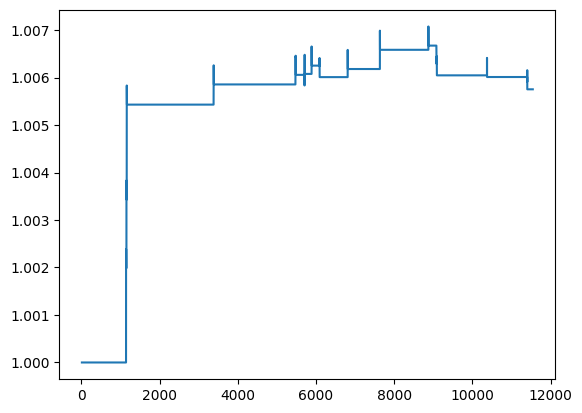

In [9]:
bt = run_backtest(df, z_entry = 4.3, z_exit = 1.9, z_window=92)

import matplotlib.pyplot as plt

plt.plot(bt.index, bt['equity'])